### Data preparation

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from keras.preprocessing.image import ImageDataGenerator

In [2]:
train_folder_path = "E:/dogs_vs_cats/train/train"
filenames = os.listdir(train_folder_path)

labels = []
for filename in filenames:
    if filename.split(".")[0] == 'cat':
        labels.append(1)
    else:
        labels.append(0)

df = pd.DataFrame({'filename': filenames,
                   'label': labels})

df.head()

,filename,label
0,cat.0.jpg,1
1,cat.1.jpg,1
2,cat.10.jpg,1
3,cat.100.jpg,1
4,cat.1000.jpg,1


In [3]:
df['label'].value_counts()

label
1    12500
0    12500
Name: count, dtype: int64

In [4]:
df['label'] = df['label'].map({0: 'dog', 1: 'cat'})

In [5]:
train_df, validation_df = train_test_split(df,
                                           test_size=0.2,
                                           random_state=42)
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

train_size = train_df.shape[0]
validation_size = validation_df.shape[0]

In [6]:
width = 150
height = 150
batch_size = 32

In [7]:
train_datagen = ImageDataGenerator(rotation_range=15,
                                   rescale=1 / 255,
                                   shear_range=0.1,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    train_folder_path,
                                                    x_col='filename',
                                                    y_col='label',
                                                    target_size=(width, height),
                                                    class_mode='categorical')

Found 20000 validated image filenames belonging to 2 classes.


In [8]:
validation_datagen = ImageDataGenerator(rescale=1 / 255)

validation_generator = validation_datagen.flow_from_dataframe(validation_df,
                                                              train_folder_path,
                                                              x_col='filename',
                                                              y_col='label',
                                                              target_size=(width, height),
                                                              class_mode='categorical',
                                                              batch_size=batch_size)

Found 5000 validated image filenames belonging to 2 classes.


In [9]:
example_df = train_df.sample(n=1).reset_index(drop=True)
example_gen = train_datagen.flow_from_dataframe(example_df,
                                                train_folder_path,
                                                x_col='filename',
                                                y_col='label',
                                                target_size=(width, height),
                                                class_mode='categorical')

Found 1 validated image filenames belonging to 1 classes.


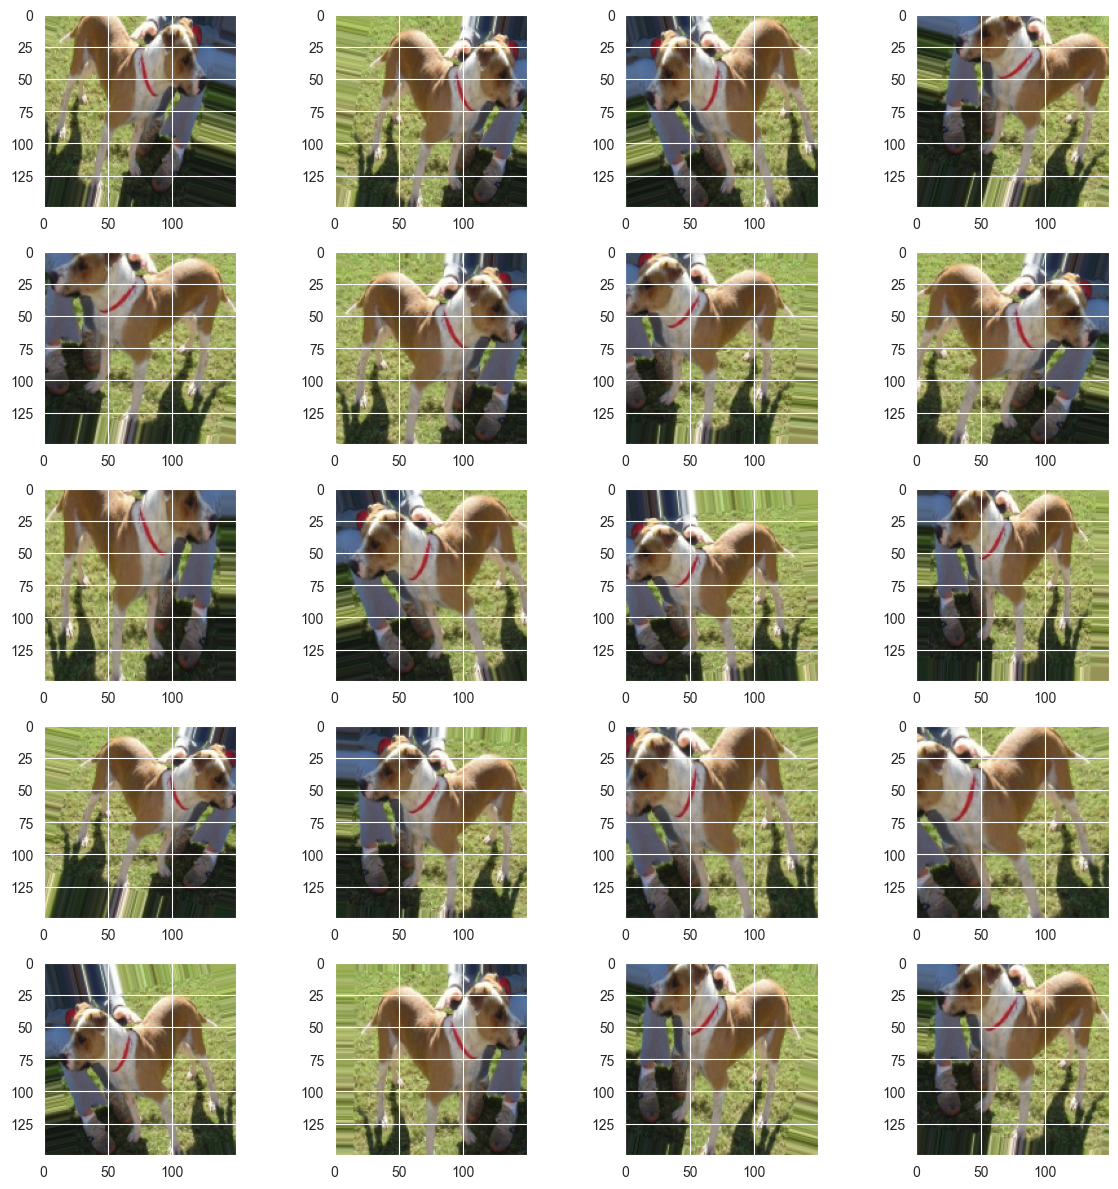

In [198]:
plt.figure(figsize=(12, 12))
for i in range(0, 20):
    plt.subplot(5, 4, i + 1)
    for x_batch, y_batch in example_gen:
        img = x_batch[0]
        plt.imshow(img)
        break
plt.tight_layout()

### Checking GPU support

In [9]:
import sys
import keras
import tensorflow as tf

print(f"tensorflow version: {tf.__version__},\nkeras version: {keras.__version__},\npython version: {sys.version}")
gpu = len(tf.config.list_physical_devices('GPU')) > 0
print(f"\nis gpu available: {gpu}")
print(f"is tensorflow built with cuda: {tf.test.is_built_with_cuda()}")

tensorflow version: 2.10.0,
keras version: 2.10.0,
python version: 3.10.4 (tags/v3.10.4:9d38120, Mar 23 2022, 23:13:41) [MSC v.1929 64 bit (AMD64)]

is gpu available: True
is tensorflow built with cuda: True


### CNN using keras Sequential

In [10]:
import pandas as pd

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [43]:
gpu_device = '/device:GPU:0'
strategy = tf.distribute.OneDeviceStrategy(device=gpu_device)

with strategy.scope():
    model = Sequential()

    # 1st convolutional layer
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=(width, height, 3)))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 2nd convolutional layer
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 3rd convolutional layer
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Dense layer
    model.add(Flatten())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(Dropout(0.25))

    # Output layer
    model.add(Dense(2, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 150, 150, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 150, 150, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 dropout_2 (Dropout)         (None, 75, 75, 32)        0         
                                                                 
 conv2d_7 (Conv2D)           (None, 75, 75, 64)       

In [11]:
# reducing the learning rate when then accuracy does not increase for 2 steps
earlystop = EarlyStopping(patience=15)

lr_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                 patience=2,
                                 verbose=1,
                                 factor=0.5,
                                 min_lr=0.00001)
callbacks = [earlystop, lr_reduction]

In [45]:
# batch_size = 500

sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))

fast = False
epochs = 5 if fast else 30

history = model.fit(train_generator,
                    epochs=epochs,
                    validation_data=validation_generator,
                    validation_steps=validation_size // batch_size,
                    steps_per_epoch=train_size // batch_size,
                    callbacks=callbacks)

sess.close()

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5

Epoch 1/30
312/312 [==============================] - 147s 464ms/step - loss: 0.7290 - accuracy: 0.6232 - val_loss: 0.6583 - val_accuracy: 0.6118 - lr: 0.0010
Epoch 2/30
312/312 [==============================] - 91s 292ms/step - loss: 0.6160 - accuracy: 0.6721 - val_loss: 0.7789 - val_accuracy: 0.5990 - lr: 0.0010
Epoch 3/30
312/312 [==============================] - 66s 210ms/step - loss: 0.5815 - accuracy: 0.6993 - val_loss: 0.5178 - val_accuracy: 0.7364 - lr: 0.0010
Epoch 4/30
312/312 [==============================] - 58s 187ms/step - loss: 0.5597 - accuracy: 0.7123 - val_loss: 0.5340 - val_accuracy: 0.7308 - lr: 0.0010
Epoch 5/30
312/312 [==============================] - ETA: 0s - loss: 0.5360 - accuracy: 0.7286
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
312/312 [=============================

<Axes: >

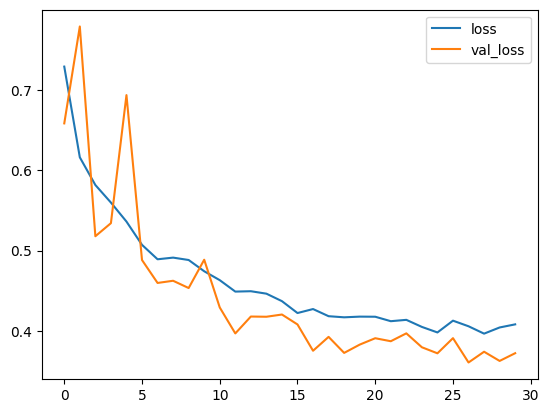

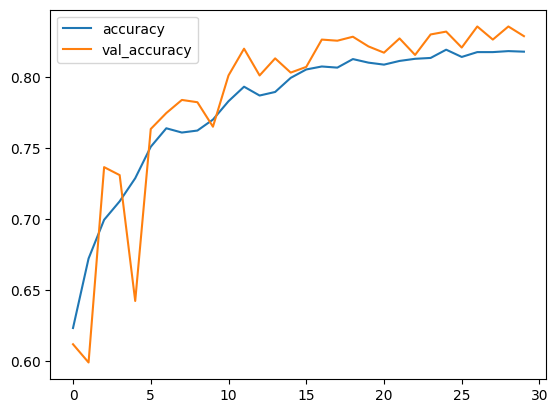

In [46]:
history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

1/1 [==============================] - 0s 155ms/step
Loss: 0.37218791246414185
Accuracy: 0.8281999826431274
F1 Score: 0.8270585866720355
Classification Report:
              precision    recall  f1-score   support

         dog       0.83      0.83      0.83      2515
         cat       0.83      0.83      0.83      2485

    accuracy                           0.83      5000
   macro avg       0.83      0.83      0.83      5000
weighted avg       0.83      0.83      0.83      5000



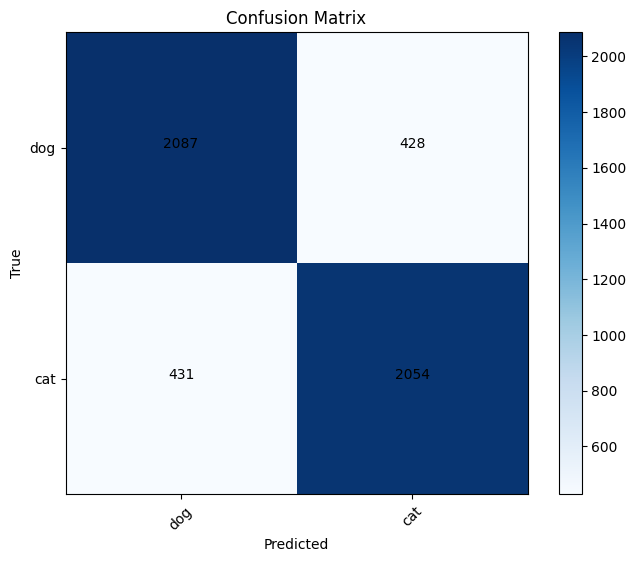

In [48]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

score = model.evaluate(validation_generator, verbose=0)
validation_steps = len(validation_generator)
val_loss, val_accuracy = score[0], score[1]

# resetting the generator to start from the beginning
validation_generator.reset()
y_true = []
y_pred = []

for i in range(validation_steps):
    x_val, y_val = next(validation_generator)
    y_true.extend(y_val)
    y_pred.extend(model.predict(x_val))

# converting predicted probabilities to binary predictions
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_true, axis=1)

f1 = f1_score(y_true, y_pred)
confusion = confusion_matrix(y_true, y_pred)

print(f"Loss: {val_loss}")
print(f"Accuracy: {val_accuracy}")
print(f"F1 Score: {f1}")

target_names = ["dog", "cat"]
report = classification_report(y_true, y_pred, target_names=target_names)
print("Classification Report:")
print(report)

plt.figure(figsize=(8, 6))
plt.imshow(confusion, interpolation='nearest', cmap=plt.get_cmap('Blues'))
plt.title('Confusion Matrix')
plt.colorbar()

# adding actual numbers to the plot
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(confusion[i, j]), horizontalalignment='center', color='black')

tick_marks = np.arange(2) # bc we have 2 classes
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

###  The same model, but trying ReLU instead of ELU

In [28]:
gpu_device = '/device:GPU:0'
strategy = tf.distribute.OneDeviceStrategy(device=gpu_device)

with strategy.scope():
    model = Sequential()

    # 1st convolutional layer
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=(width, height, 3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 2nd convolutional layer
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 3rd convolutional layer
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Dense layer
    model.add(Flatten())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))

    # Output layer
    model.add(Dense(2, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 150, 150, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 dropout_3 (Dropout)         (None, 75, 75, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)       

In [29]:
# batch_size = 500

sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))

fast = False
epochs = 5 if fast else 30

history = model.fit(train_generator,
                    epochs=epochs,
                    validation_data=validation_generator,
                    validation_steps=validation_size // batch_size,
                    steps_per_epoch=train_size // batch_size,
                    callbacks=callbacks)

sess.close()

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5

Epoch 1/30
312/312 [==============================] - 174s 550ms/step - loss: 0.6738 - accuracy: 0.6283 - val_loss: 0.7809 - val_accuracy: 0.5088 - lr: 0.0010
Epoch 2/30
312/312 [==============================] - 106s 338ms/step - loss: 0.5819 - accuracy: 0.6988 - val_loss: 0.6007 - val_accuracy: 0.6771 - lr: 0.0010
Epoch 3/30
312/312 [==============================] - 76s 243ms/step - loss: 0.5455 - accuracy: 0.7205 - val_loss: 0.7854 - val_accuracy: 0.5998 - lr: 0.0010
Epoch 4/30
312/312 [==============================] - 61s 195ms/step - loss: 0.5187 - accuracy: 0.7421 - val_loss: 0.6685 - val_accuracy: 0.6967 - lr: 0.0010
Epoch 5/30
312/312 [==============================] - 55s 176ms/step - loss: 0.4928 - accuracy: 0.7645 - val_loss: 0.5530 - val_accuracy: 0.7456 - lr: 0.0010
Epoch 6/30
312/312 [==============================]

<Axes: >

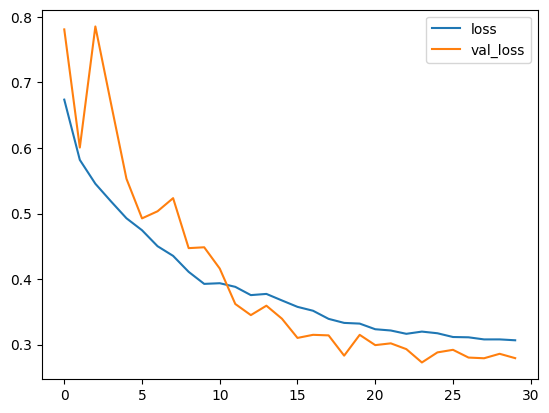

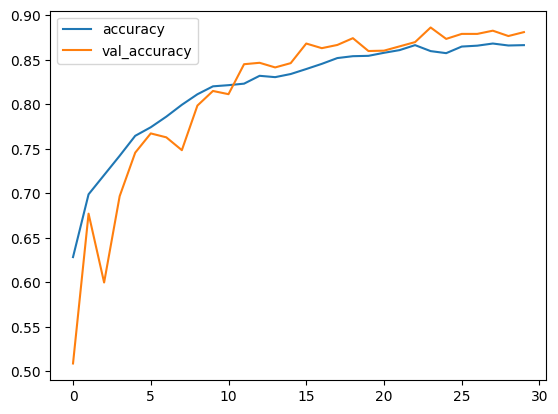

In [30]:
history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

1/1 [==============================] - 0s 160ms/step
Loss: 0.2748556137084961
Accuracy: 0.881600022315979
F1 Score: 0.8793806030969845
Classification Report:
              precision    recall  f1-score   support

         dog       0.87      0.89      0.88      2515
         cat       0.89      0.87      0.88      2485

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



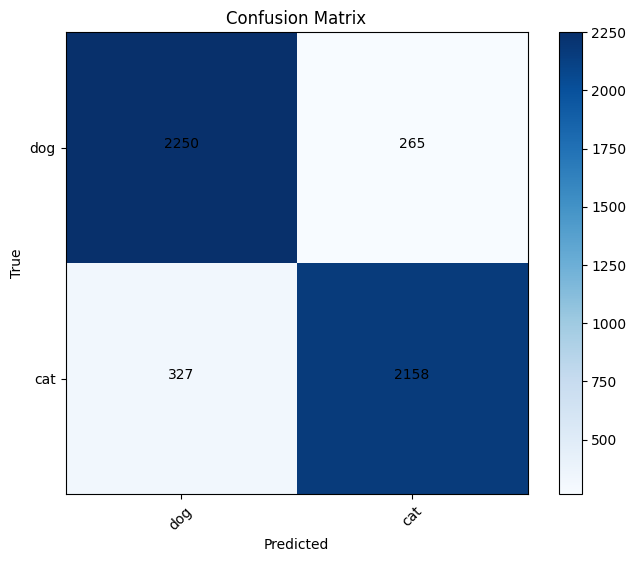

In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

score = model.evaluate(validation_generator, verbose=0)
validation_steps = len(validation_generator)
val_loss, val_accuracy = score[0], score[1]

# resetting the generator to start from the beginning
validation_generator.reset()
y_true = []
y_pred = []

for i in range(validation_steps):
    x_val, y_val = next(validation_generator)
    y_true.extend(y_val)
    y_pred.extend(model.predict(x_val))

# converting predicted probabilities to binary predictions
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_true, axis=1)

f1 = f1_score(y_true, y_pred)
confusion = confusion_matrix(y_true, y_pred)

print(f"Loss: {val_loss}")
print(f"Accuracy: {val_accuracy}")
print(f"F1 Score: {f1}")

target_names = ["dog", "cat"]
report = classification_report(y_true, y_pred, target_names=target_names)
print("Classification Report:")
print(report)

plt.figure(figsize=(8, 6))
plt.imshow(confusion, interpolation='nearest', cmap=plt.get_cmap('Blues'))
plt.title('Confusion Matrix')
plt.colorbar()

# adding actual numbers to the plot
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(confusion[i, j]), horizontalalignment='center', color='black')

tick_marks = np.arange(2) # bc we have 2 classes
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### A much simpler keras Sequential model to see the difference (and test if my own model would work with this architecture)

In [13]:
gpu_device = '/device:GPU:0'
strategy = tf.distribute.OneDeviceStrategy(device=gpu_device)

with strategy.scope():
    model = Sequential()

    # 1st convolutional layer
    model.add(Conv2D(5, (3, 3), padding='same', input_shape=(width, height, 3), activation='relu'))

    # 2nd convolutional layer
    model.add(Conv2D(5, (3, 3), padding='same', activation='relu'))

    # Dense layer
    model.add(Flatten())
    model.add(Dense(256, activation='sigmoid'))

    # Output layer
    model.add(Dense(2, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))

fast = True
epochs = 5 if fast else 30

history = model.fit(train_generator,
                    epochs=epochs,
                    validation_data=validation_generator,
                    validation_steps=validation_size // batch_size,
                    steps_per_epoch=train_size // batch_size)

sess.close()

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5

Epoch 1/5
625/625 [==============================] - 470s 751ms/step - loss: 0.6760 - accuracy: 0.6118 - val_loss: 0.6296 - val_accuracy: 0.6416
Epoch 2/5
625/625 [==============================] - 94s 150ms/step - loss: 0.5991 - accuracy: 0.6719 - val_loss: 0.5574 - val_accuracy: 0.7063
Epoch 3/5
625/625 [==============================] - 92s 147ms/step - loss: 0.5673 - accuracy: 0.7033 - val_loss: 0.5518 - val_accuracy: 0.7216
Epoch 4/5
625/625 [==============================] - 95s 151ms/step - loss: 0.5417 - accuracy: 0.7222 - val_loss: 0.5362 - val_accuracy: 0.7272
Epoch 5/5
625/625 [==============================] - 96s 153ms/step - loss: 0.5243 - accuracy: 0.7374 - val_loss: 0.4984 - val_accuracy: 0.7520


### Pre-Trained ResNet-50

In [25]:
from keras.models import Sequential
from keras.applications import ResNet50
from keras.layers import Dense

model = Sequential()
model.add(ResNet50(include_top=False, pooling='max', weights="imagenet"))
model.add(Dense(2, activation='softmax'))
model.layers[0].trainable = True

model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

epochs = 20
batch_size = 64

sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))

history = model.fit(train_generator,
                    steps_per_epoch=train_generator.samples // batch_size,
                    epochs=epochs,
                    validation_data=validation_generator,
                    validation_steps=validation_generator.samples // batch_size)

sess.close()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense_13 (Dense)            (None, 2)                 4098      
                                                                 
Total params: 23,591,810
Trainable params: 23,538,690
Non-trainable params: 53,120
_________________________________________________________________
Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5

Epoch 1/20
312/312 [==============================] - 184s 574ms/step - loss: 2.0200 - accuracy: 0.6606 - val_loss: 0.8944 - val_accuracy: 0.5044
Epoch 2/20
312/312 [==============================] - 126s 404ms/step - loss: 0.5296 - accuracy: 0.7651 - val_loss: 0.6787 - val_a

In [26]:
model.save("resnet50.h5")
model.save_weights("resnet50_weights.h5")

In [27]:
from keras.models import load_model

loaded_model = load_model("C:/Egyetem/deep_learning/dogs-vs-cats/resnet50.h5")
loaded_model.load_weights("C:/Egyetem/deep_learning/dogs-vs-cats/resnet50_weights.h5")

sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))
score = loaded_model.evaluate(validation_generator, verbose=0)
sess.close()

print('validation loss:', score[0])
print('validation accuracy:', score[1])

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5

validation loss: 0.09760980308055878
validation accuracy: 0.9649999737739563


<Axes: >

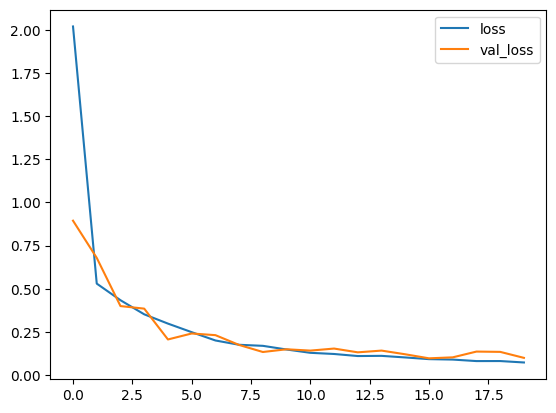

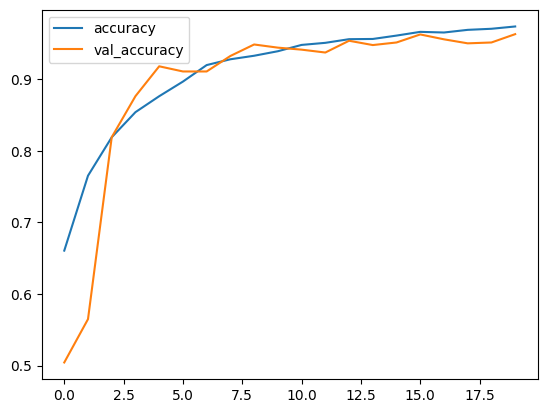

In [28]:
history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

1/1 [==============================] - 0s 25ms/step
Loss: 0.09760980308055878
Accuracy: 0.9649999737739563
F1 Score: 0.9648805940196669
Classification Report:
              precision    recall  f1-score   support

         dog       0.97      0.96      0.97      2515
         cat       0.96      0.97      0.96      2485

    accuracy                           0.96      5000
   macro avg       0.96      0.97      0.96      5000
weighted avg       0.97      0.96      0.97      5000



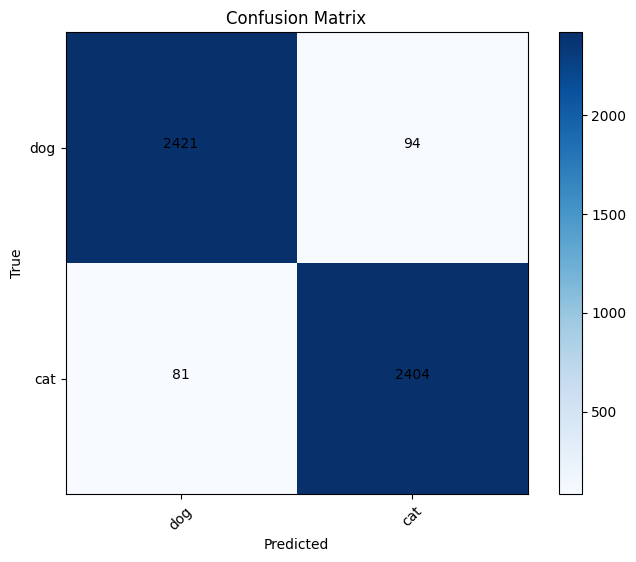

In [41]:
validation_steps = len(validation_generator)
val_loss, val_accuracy = score[0], score[1]

# Make predictions on the validation dataset
validation_generator.reset()  # Reset the generator to start from the beginning
y_true = []
y_pred = []

for i in range(validation_steps):
    x_val, y_val = next(validation_generator)
    y_true.extend(y_val)
    y_pred.extend(model.predict(x_val))

# converting predicted probabilities to binary predictions
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_true, axis=1)

f1 = f1_score(y_true, y_pred)
confusion = confusion_matrix(y_true, y_pred)

print(f"Loss: {val_loss}")
print(f"Accuracy: {val_accuracy}")
print(f"F1 Score: {f1}")

target_names = ["dog", "cat"]
report = classification_report(y_true, y_pred, target_names=target_names)
print("Classification Report:")
print(report)

plt.figure(figsize=(8, 6))
plt.imshow(confusion, interpolation='nearest', cmap=plt.get_cmap('Blues'))
plt.title('Confusion Matrix')
plt.colorbar()

# adding actual numbers to the plot
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(confusion[i, j]), horizontalalignment='center', color='black')

tick_marks = np.arange(2) # bc we have 2 classes
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### VGG16

In [20]:
from keras.applications import VGG16

model = Sequential()
model.add(VGG16(include_top=False, pooling='max', weights="imagenet"))
model.add(Dense(2, activation='softmax'))
model.layers[0].trainable = True

model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

epochs = 20
batch_size = 64

sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))

history = model.fit(train_generator,
                    steps_per_epoch=train_generator.samples // batch_size,
                    epochs=epochs,
                    validation_data=validation_generator,
                    validation_steps=validation_generator.samples // batch_size)

sess.close()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 512)               14714688  
                                                                 
 dense_6 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 14,715,714
Trainable params: 14,715,714
Non-trainable params: 0
_________________________________________________________________
Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5

Epoch 1/20
312/312 [==============================] - 202s 642ms/step - loss: 0.3292 - accuracy: 0.8449 - val_loss: 0.1085 - val_accuracy: 0.9515
Epoch 2/20
312/312 [==============================] - 152s 485ms/step - loss: 0.1323 - accuracy: 0.9493 - val_loss: 0.0837 - val_accuracy

In [21]:
model.save("vgg16.h5")
model.save_weights("vgg16_weights.h5")

In [22]:
from keras.models import load_model

loaded_model = load_model("C:/Egyetem/deep_learning/dogs-vs-cats/vgg16.h5")
loaded_model.load_weights("C:/Egyetem/deep_learning/dogs-vs-cats/vgg16_weights.h5")

sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))
score = loaded_model.evaluate(validation_generator, verbose=0)
sess.close()

print('validation loss:', score[0])
print('validation accuracy:', score[1])

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5

validation loss: 0.047883108258247375
validation accuracy: 0.984000027179718


<Axes: >

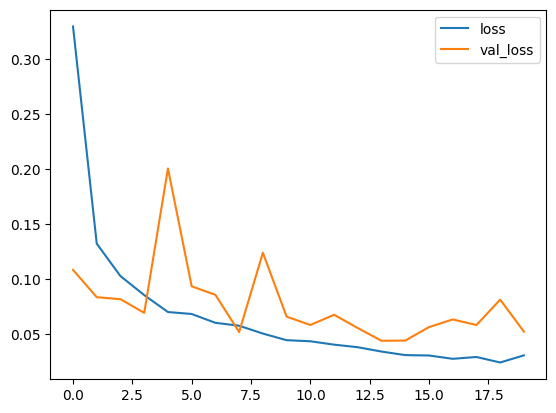

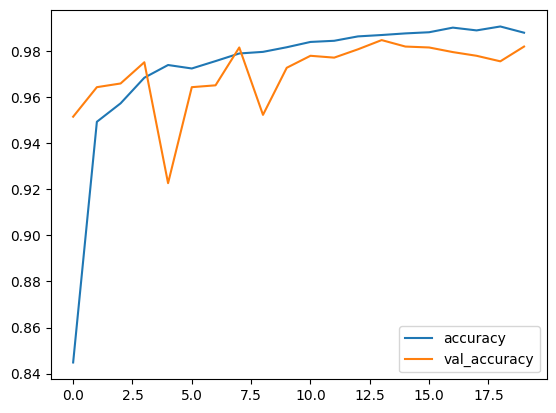

In [27]:
history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

1/1 [==============================] - 0s 20ms/step
Loss: 0.04788309708237648
Accuracy: 0.984000027179718
F1 Score: 0.9839550742077817
Classification Report:
              precision    recall  f1-score   support

         dog       0.99      0.98      0.98      2515
         cat       0.98      0.99      0.98      2485

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



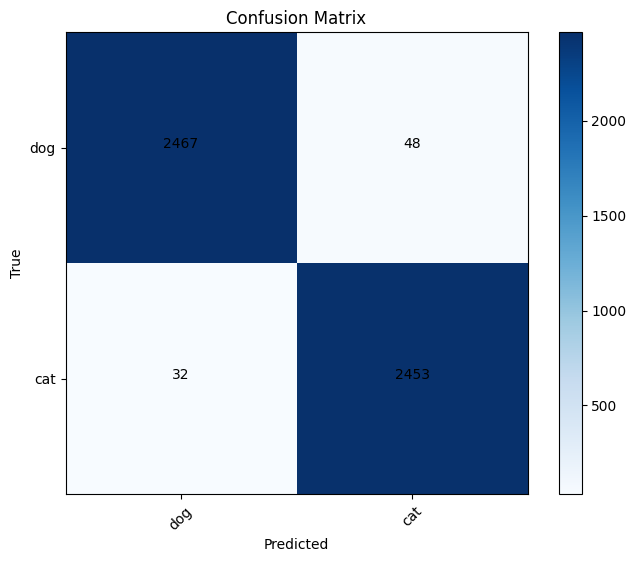

In [24]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

score = model.evaluate(validation_generator, verbose=0)
validation_steps = len(validation_generator)
val_loss, val_accuracy = score[0], score[1]

# resetting the generator to start from the beginning
validation_generator.reset()
y_true = []
y_pred = []

for i in range(validation_steps):
    x_val, y_val = next(validation_generator)
    y_true.extend(y_val)
    y_pred.extend(model.predict(x_val))

# converting predicted probabilities to binary predictions
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_true, axis=1)

f1 = f1_score(y_true, y_pred)
confusion = confusion_matrix(y_true, y_pred)

print(f"Loss: {val_loss}")
print(f"Accuracy: {val_accuracy}")
print(f"F1 Score: {f1}")

target_names = ["dog", "cat"]
report = classification_report(y_true, y_pred, target_names=target_names)
print("Classification Report:")
print(report)

plt.figure(figsize=(8, 6))
plt.imshow(confusion, interpolation='nearest', cmap=plt.get_cmap('Blues'))
plt.title('Confusion Matrix')
plt.colorbar()

# adding actual numbers to the plot
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(confusion[i, j]), horizontalalignment='center', color='black')

tick_marks = np.arange(2) # bc we have 2 classes
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()